## What Is Transfer Learning?

- Transfer learning is a machine learning technique where model is trained on one task usually big dataset is then reused as starting point on another related task this allows model to perform better especially when dataset is limited. Doing this also decreases the training time, 

### What does "transfer" mean in transfer learning?
- "transfer" means using the weights of model trained on another dataset as starting point thus transferring learning of another model and then fine tuning it to use in related application. 

### What exactly is transferred from a pre-trained model?
- weights of neural network are being transferred from pre-trained model.

### Are the original model's final classification outputs transferred?
- No model's final classification output may be of entirely different problem so that might be of no use to us in our application but instead we transfer model's ability to extract features from raw data.

### Why might features learned from one image dataset be useful on another?
- Because CNN extracts features something like this "lines -> texture -> shapes -> objects" where each feature extraction depends on previous layers feature map so according to this every image should contain lines and textures as well as shapes since they must appear in every object to make up an object. Thus we can use transfer learning to get more performance on small dataset.

## Why Not Train Everything From Scratch?

### What problems might you encounter when training a CNN from scratch?

- Training a CNN from scratch generally requires more data and computation because the model must learn all useful representations from random initialization. With limited data, a high-capacity model can overfit. Training may also require more careful optimization and hyperparameter tuning.

### What happens when the dataset is small relative to model capacity?

- A model with high capacity relative to a small dataset can memorize training-specific patterns and noise, resulting in low training error but poor generalization.

### Why might a pre-trained model reduce the amount of data required?
- A pretrained model can reduce target-data requirements because it already contains learned representations that may be useful for the target task. The target model can therefore focus on adapting those representations rather than learning all visual features from random initialization.


## Pretrained Model

In [19]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

### What does weights=weights do?
- It sets the weight of `resnet18` model which we created thus we get initial weights of pre-trained model instead of random weight.

### What does "pre-trained" mean here?
- It means model has already been trained and it has already adjusted it's weight. 

### What dataset was the model originally trained on?
- Model was originally trained on ImageNet dataset.

### Why does that matter?
- ImageNet-1K contains around 1.28 million training images across 1,000 classes. Training ResNet-18 on this large and diverse dataset allows it to learn useful visual representations such as edges, textures, shapes, and higher-level patterns. These learned representations can then be transferred to a related image-classification task, reducing the amount of visual structure the model needs to learn from scratch.

## Inspect the Architecture

In [20]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

### Where is the final classification layer?
- At last it is a linear layer which classifies 512 features into 1000 classes.

### What is the input to that layer?
- Input of that layer is 512 numerical feature along with an image with very small spacial dimension.

### How many classes does the original model predict?
- Original model has 1000 classes to predict.

## Freeze the Backbone

In [21]:
for param in model.parameters():
    param.requires_grad = False

model.fc.requires_grad_(True)

Linear(in_features=512, out_features=1000, bias=True)

### Which parameters are now trainable?
- Only parameters of classifier (i.e. linear layer) are trainable. 

### Which parameters remain frozen?
- all the parameters of feature extraction layers remains frozen.

### Why is the classification head still trainable?
- The classification head remains trainable because it is responsible for mapping the pretrained feature representation to the target task's classes. Since the original classifier was designed for ImageNet's 1000 classes, we replace it with a new classifier whose parameters must be learned for our target dataset.

## Fine-Tuning vs Feature Extraction

### Fine-Tuning :-
- Fine-Tuning involves unfreezing some or all of the parameters of pre-trained model's feature extraction layers and training it on target dataset using a low learning rate this allows model to identify complex patterns and task specific features representation. It is more computationally intensive and used when the target task/domain is different enough that the frozen pretrained representation isn't sufficient.

### Feature Extraction :- 
- Feature Extraction involves freezing the parameters of pre-trained model's feature extraction layers and only training classifier (i.e. linear layer) to classify target dataset's class based on feature extracted. It is computationally inexpensive and used when source dataset and target dataset are similar also it is ideal for small datasets.

### What is the difference?
- Feature extraction: freeze the pretrained backbone and train only the new task-specific head.
- Fine-tuning: unfreeze some or all of the pretrained backbone and update those parameters along with the task-specific head.

### Which one are you currently doing?
- I am currently doing Feature Extraction as ResNet is already trained on images to classify them i need to just use it's feature extractor and train classifier to fit my target dataset.

### When might fine-tuning be preferable?
- Fine-tuning is preferable when the pretrained features are not sufficiently suited to the target task or domain. By updating some of the pretrained layers, the model can adapt its learned representations to the target data.

## Dataset

### What makes CIFAR-10 different from ImageNet?
- CIFAR-10 contains 60,000 RGB images of size 32×32 pixels, divided into 10 classes. It has 50,000 training images and 10,000 test images.
- ImageNet-1K, which the pretrained ResNet-18 was trained on, contains roughly 1.28 million training images across 1,000 classes. Its original images are much larger and have varying resolutions.
- Therefore, CIFAR-10 is much smaller and has significantly lower-resolution images than ImageNet-1K.
- This creates a domain/input difference when using an ImageNet-pretrained model on CIFAR-10, so the CIFAR-10 images need to be appropriately preprocessed before being passed to ResNet-18.

### What preprocessing does a pre-trained ResNet expect?
- The standard ImageNet-pretrained ResNet-18 expects 3-channel RGB images that are transformed to the input format used during ImageNet training.
- For the standard ResNet-18 weights, the preprocessing includes resizing/cropping the image to 224×224 pixels, converting it to a tensor, scaling pixel values, and normalizing the channels using the ImageNet mean and standard deviation.

## Preprocessing

In [22]:
weights = ResNet18_Weights.DEFAULT
transform = weights.transforms()

### Why should preprocessing match what the pre-trained model expects?
- Preprocessing should match the preprocessing used during pretraining because the model's parameters were learned from data with a particular input distribution. Matching the preprocessing helps ensure that target images are represented in a form compatible with the features learned by the pretrained model.

### Why isn't simply converting the image to a tensor sufficient?
- Converting an image to a tensor only changes its representation into a tensor. It does not necessarily resize the image, scale its pixel values, or normalize it according to the distribution expected by the pretrained model. These transformations are important because the pretrained weights were learned using a specific preprocessing pipeline.

## Train the New Classification Head

### Creating Dataset

In [23]:
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset

class CIFAR10Dataset(Dataset):
    
    def __init__(self, image_dir, labels_file, transform=None):
        super().__init__()
        
        self.image_dir = image_dir
        self.labels = pd.read_csv(labels_file)
        self.transform = transform
        
        self.label_map = {label_name : idx for idx, label_name in enumerate(sorted(self.labels["label"].unique()))}

        self.labels["label_map"] = [self.label_map[label] for label in self.labels["label"]]
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, index):
        
        row = self.labels.iloc[index]
        
        label = row["label_map"]
        filename = str(row["id"]) + ".png"
        
        image = Image.open(os.path.join(self.image_dir, filename)).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

### Making a function to plot train and validation losses

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def plot_train_val_loss_curve(train_losses, validation_losses, title):
    
    train_losses = np.array(train_losses)
    validation_losses = np.array(validation_losses)

    train_min_idx = np.argmin(train_losses)
    val_min_idx = np.argmin(validation_losses)

    plt.plot(validation_losses, label='Validation Loss')
    plt.plot(train_losses, label="Training Loss")

    plt.scatter(train_min_idx, train_losses[train_min_idx])
    plt.scatter(val_min_idx, validation_losses[val_min_idx])

    plt.annotate(
        f"Epoch {val_min_idx}\n{validation_losses[val_min_idx]:.4f}",
        (float(val_min_idx), validation_losses[val_min_idx]),
        xytext=(10, 10),
        textcoords="offset points",
    )

    plt.annotate(
        f"Epoch {train_min_idx}\n{train_losses[train_min_idx]:.4f}",
        (float(train_min_idx), train_losses[train_min_idx]),
        xytext=(10, -15),
        textcoords="offset points",
    )

    plt.legend()
    plt.title(title)
    plt.show()
    
def plot_train_val_accuracy_curve(train_accuracies, validation_accuracies, title):
    
    train_accuracies = np.array(train_accuracies)
    validation_accuracies = np.array(validation_accuracies)

    train_min_idx = np.argmax(train_accuracies)
    val_min_idx = np.argmax(validation_accuracies)

    plt.plot(validation_accuracies, label='Validation Accuracy')
    plt.plot(train_accuracies, label="Training Accuracy")

    plt.scatter(train_min_idx, train_accuracies[train_min_idx])
    plt.scatter(val_min_idx, validation_accuracies[val_min_idx])

    plt.annotate(
        f"Epoch {val_min_idx}\n{validation_accuracies[val_min_idx]:.4f}",
        (float(val_min_idx), validation_accuracies[val_min_idx]),
        xytext=(10, 10),
        textcoords="offset points",
    )

    plt.annotate(
        f"Epoch {train_min_idx}\n{train_accuracies[train_min_idx]:.4f}",
        (float(train_min_idx), train_accuracies[train_min_idx]),
        xytext=(10, -15),
        textcoords="offset points",
    )

    plt.legend()
    plt.title(title)
    plt.show()

### Creating DataLoader for training and validation

In [25]:
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.model_selection import train_test_split
import torch

weights = ResNet18_Weights.DEFAULT
pretrained_transform = weights.transforms()

dataset = CIFAR10Dataset("../../datasets/cifar-10/train/", "../../datasets/cifar-10/trainLabels.csv", pretrained_transform)

indices = list(range(len(dataset)))
labels = list(dataset.labels["label_map"].values)

train_indices, val_indices = train_test_split(
	indices,
	test_size=0.2,
	stratify=labels,
	random_state=42 
)

train_set = Subset(dataset, train_indices)
val_set = Subset(dataset, val_indices)

batch_s = 256

pretrained_train_loader = DataLoader(
	train_set,
	batch_size=batch_s,
	shuffle=True
)

pretrained_val_loader = DataLoader(
	val_set,
	batch_size=batch_s,
	shuffle=False
)

### Training Loop

In [26]:
import torch.nn as nn
import os
import gc

device = torch.device("cuda")

pretrained_model = resnet18(weights=weights)

pretrained_model.fc = nn.Linear(pretrained_model.fc.in_features, 10)

for param in pretrained_model.parameters():
    param.requires_grad = False

pretrained_model.fc.requires_grad_(True)

pretrained_model = pretrained_model.to(device)

print("Trainable Parameters : ",sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad))

optimizer = torch.optim.Adam(
    pretrained_model.parameters(),
    lr=1e-3
)

pretrained_train_losses = []
pretrained_val_losses = []
pretrained_train_accuracies = []
pretrained_val_accuracies = []

loss_fn = nn.CrossEntropyLoss()

best_val_loss = float("inf")

pretrained_checkpoint_path = "/home/taksh/Coding/Learn/ml-learning-journey/static/tmp"

if os.path.exists(os.path.join(pretrained_checkpoint_path, "best_pretrained.pt")):
    pretrained_model.load_state_dict(torch.load(
        os.path.join(pretrained_checkpoint_path, "best_pretrained.pt"),
        map_location=device
    ))

    pretrained_train_losses = np.load(os.path.join(pretrained_checkpoint_path, "pretrained_train_losses.npy"))
    pretrained_val_losses = np.load(os.path.join(pretrained_checkpoint_path, "pretrained_val_losses.npy"))
    pretrained_train_accuracies = np.load(os.path.join(pretrained_checkpoint_path, "pretrained_train_accuracies.npy"))
    pretrained_val_accuracies = np.load(os.path.join(pretrained_checkpoint_path, "pretrained_val_accuracies.npy"))

if not os.path.exists(os.path.join(pretrained_checkpoint_path, "best_pretrained.pt")):
    
    for epoch in range(30):
        
        pretrained_model.train()
            
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in pretrained_train_loader:
            
            images = images.to(device)
            labels = labels.to(device)

            pred = pretrained_model(images)
            
            loss = loss_fn(pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
            correct += (pred.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(pretrained_train_loader)
        train_accuracy = correct / total
            
        # Validation
        pretrained_model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in pretrained_val_loader:
                
                images = images.to(device)
                labels = labels.to(device)

                pred = pretrained_model(images)
                
                loss = loss_fn(pred, labels)

                val_loss += loss.item()
                
                correct += (pred.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(pretrained_val_loader)
        val_accuracy = correct / total

        print(
            f"Epoch: {epoch:02} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f} | "
        )
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(pretrained_model.state_dict(), os.path.join(pretrained_checkpoint_path, "best_pretrained.pt"))

        pretrained_train_losses.append(train_loss)
        pretrained_val_losses.append(val_loss)
        pretrained_train_accuracies.append(train_accuracy)
        pretrained_val_accuracies.append(val_accuracy)

    np.save(os.path.join(pretrained_checkpoint_path, "pretrained_train_losses.npy"), pretrained_train_losses)
    np.save(os.path.join(pretrained_checkpoint_path, "pretrained_val_losses.npy"), pretrained_val_losses)
    np.save(os.path.join(pretrained_checkpoint_path, "pretrained_train_accuracies.npy"), pretrained_train_accuracies)
    np.save(os.path.join(pretrained_checkpoint_path, "pretrained_val_accuracies.npy"), pretrained_val_accuracies)

gc.collect()
torch.cuda.empty_cache()

Trainable Parameters :  5130


## Compare With Your CNN From Scratch

In [27]:
class CNNfromScratch(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)

        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features=4*4*128, out_features=10)
        )

    def forward(self, x):

        x = self.features(x)
        x = torch.flatten(x, start_dim=1)

        x = self.classifier(x)
        return x

### Creating DataLoader for training and validation

In [28]:
from torchvision import transforms

scratch_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

dataset = CIFAR10Dataset("../../datasets/cifar-10/train/", "../../datasets/cifar-10/trainLabels.csv", scratch_transform)

indices = list(range(len(dataset)))
labels = list(dataset.labels["label_map"].values)

train_indices, val_indices = train_test_split(
	indices,
	test_size=0.2,
	stratify=labels,
	random_state=42 
)

train_set = Subset(dataset, train_indices)
val_set = Subset(dataset, val_indices)

scratch_train_loader = DataLoader(
	train_set,
	batch_size=batch_s,
	shuffle=True
)

scratch_val_loader = DataLoader(
	val_set,
	batch_size=batch_s,
	shuffle=False
)

In [29]:
scratch_model = CNNfromScratch()

device = torch.device("cuda")

scratch_model = scratch_model.to(device)

optimizer = torch.optim.Adam(
    scratch_model.parameters(),
    lr=1e-3
)

scratch_model_train_losses = []
scratch_model_val_losses = []
scratch_model_train_accuracies = []
scratch_model_val_accuracies = []

loss_fn = nn.CrossEntropyLoss()

best_val_loss = float("inf")

scratch_checkpoint_path = "/home/taksh/Coding/Learn/ml-learning-journey/static/tmp"

if os.path.exists(os.path.join(scratch_checkpoint_path, "best_scratch_cnn.pt")):
    scratch_model.load_state_dict(torch.load(
        os.path.join(scratch_checkpoint_path, "best_scratch_cnn.pt"),
        map_location=device
    ))

    scratch_model_train_losses = np.load(os.path.join(scratch_checkpoint_path, "scratch_model_train_losses.npy"))
    scratch_model_val_losses = np.load(os.path.join(scratch_checkpoint_path, "scratch_model_val_losses.npy"))
    scratch_model_train_accuracies = np.load(os.path.join(scratch_checkpoint_path, "scratch_model_train_accuracies.npy"))
    scratch_model_val_accuracies = np.load(os.path.join(scratch_checkpoint_path, "scratch_model_val_accuracies.npy"))

if not os.path.exists(os.path.join(scratch_checkpoint_path, "best_scratch_cnn.pt")):
    
    for epoch in range(30):
        
        scratch_model.train()
            
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in scratch_train_loader:
            
            images = images.to(device)
            labels = labels.to(device)

            pred = scratch_model(images)
            
            loss = loss_fn(pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
            correct += (pred.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(scratch_train_loader)
        train_accuracy = correct / total
            
        # Validation
        scratch_model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in scratch_val_loader:
                
                images = images.to(device)
                labels = labels.to(device)

                pred = scratch_model(images)
                
                loss = loss_fn(pred, labels)

                val_loss += loss.item()
                
                correct += (pred.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(scratch_val_loader)
        val_accuracy = correct / total

        print(
            f"Epoch: {epoch:02} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f} | "
        )
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(scratch_model.state_dict(), os.path.join(scratch_checkpoint_path, "best_scratch_cnn.pt"))

        scratch_model_train_losses.append(train_loss)
        scratch_model_val_losses.append(val_loss)
        scratch_model_train_accuracies.append(train_accuracy)
        scratch_model_val_accuracies.append(val_accuracy)

    np.save(os.path.join(scratch_checkpoint_path, "scratch_model_train_losses.npy"), scratch_model_train_losses)
    np.save(os.path.join(scratch_checkpoint_path, "scratch_model_val_losses.npy"), scratch_model_val_losses)
    np.save(os.path.join(scratch_checkpoint_path, "scratch_model_train_accuracies.npy"), scratch_model_train_accuracies)
    np.save(os.path.join(scratch_checkpoint_path, "scratch_model_val_accuracies.npy"), scratch_model_val_accuracies)

gc.collect()
torch.cuda.empty_cache()

## Comparing Pretrained and Model Built from Scratch.

### Comparing Number of parameters

In [30]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

pretrained_model_pram = count_parameters(pretrained_model)
scratch_model_pram = count_parameters(scratch_model)

print("Pretrained Model (Only classifier (linear layer)):",pretrained_model_pram )
print("Model built from Scratch:", scratch_model_pram)

Pretrained Model (Only classifier (linear layer)): 5130
Model built from Scratch: 113738


In [31]:
scratch_model_pram / pretrained_model_pram 

22.171150097465887

- Pretrained Model has 22 times less trainable parameters than Model created from Scratch.

### Comparing training loss vs validation loss

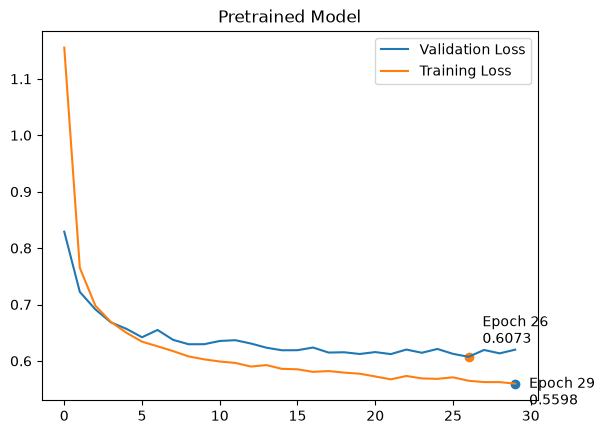

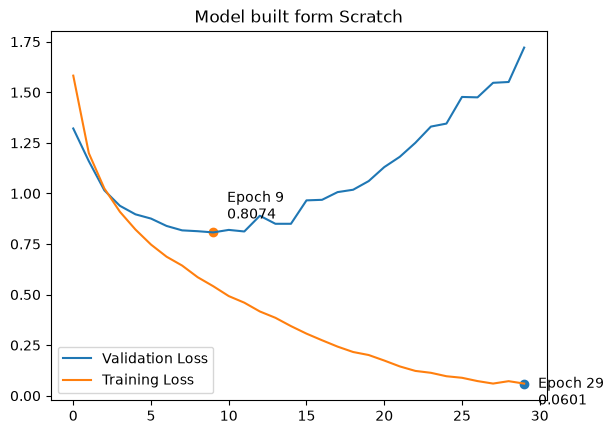

In [32]:
plot_train_val_loss_curve(pretrained_train_losses, pretrained_val_losses, "Pretrained Model")
plot_train_val_loss_curve(scratch_model_train_losses, scratch_model_val_losses, "Model built form Scratch")

- Model built from Scratch is overfitting the data as training loss keeps decreasing while validation loss start increasing after epoch 9 on other hand pretrained model is steadily decreasing both training and validation loss.

### Comparing training accuracy vs validation accuracy

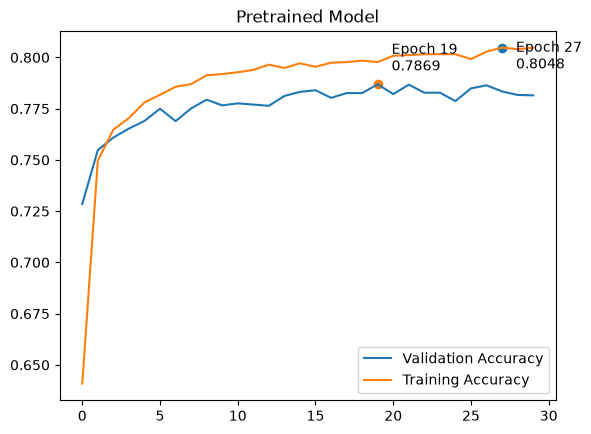

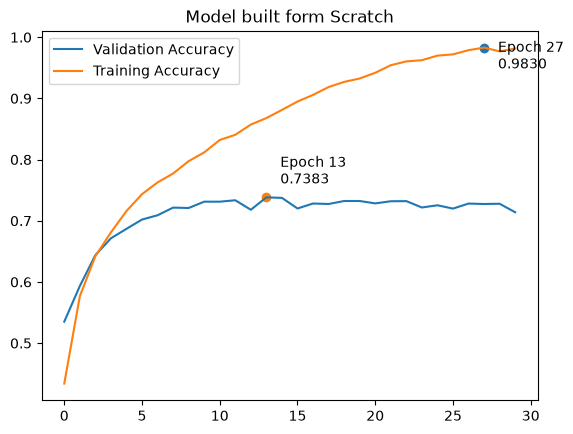

In [33]:
plot_train_val_accuracy_curve(pretrained_train_accuracies, pretrained_val_accuracies, "Pretrained Model")
plot_train_val_accuracy_curve(scratch_model_train_accuracies, scratch_model_val_accuracies, "Model built form Scratch")

- Here too we can observe that training loss of model built from scratch is reaching is reaching near 1 while validation accuracy is only 0.74 which indicates overfitting but for pretrained model both are much more closer. It's validation accuracy is 0.78 which is significantly greater. 

### Classification Report

In [34]:
from sklearn.metrics import classification_report

pretrained_model = resnet18(weights=None)

pretrained_model.fc = nn.Linear(in_features=pretrained_model.fc.in_features, out_features=10)

pretrained_model.load_state_dict(
    torch.load(os.path.join(pretrained_checkpoint_path, "best_pretrained.pt"), map_location=device)
)

pretrained_model = pretrained_model.to(device)

scratch_model = CNNfromScratch()

scratch_model.load_state_dict(
    torch.load(os.path.join(scratch_checkpoint_path, "best_scratch_cnn.pt"), map_location=device)
)

scratch_model = scratch_model.to(device)

pretrained_model.eval()
scratch_model.eval()

pretrained_predictions = []
scratch_predictions = []
true_labels = []

with torch.no_grad():

    for images, labels in pretrained_val_loader:

        images = images.to(device)
        labels = labels.to(device)

        pretrained_output = pretrained_model(images)

        pretrained_predictions.extend(
            pretrained_output.argmax(dim=1).cpu().numpy()
        )

    for images, labels in scratch_val_loader:

        images = images.to(device)
    
        scratch_output = scratch_model(images)

        scratch_predictions.extend(
            scratch_output.argmax(dim=1).cpu().numpy()
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

print(
    "Pretrained Model:\n",
    classification_report(true_labels, pretrained_predictions)
)

print(
    "Model Built From Scratch:\n",
    classification_report(true_labels, scratch_predictions)
)

gc.collect()
torch.cuda.empty_cache()

Pretrained Model:
               precision    recall  f1-score   support

           0       0.80      0.81      0.81      1000
           1       0.88      0.90      0.89      1000
           2       0.71      0.74      0.73      1000
           3       0.65      0.68      0.67      1000
           4       0.76      0.73      0.74      1000
           5       0.77      0.72      0.75      1000
           6       0.82      0.82      0.82      1000
           7       0.77      0.76      0.77      1000
           8       0.84      0.85      0.85      1000
           9       0.88      0.84      0.86      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000

Model Built From Scratch:
               precision    recall  f1-score   support

           0       0.80      0.75      0.77      1000
           1       0.91      0.76      0.83      1000
           2       0.71      0.5

### Which model performs better?
- For this experiment, the ImageNet-pretrained ResNet18 used as a frozen feature extractor achieved better CIFAR-10 validation performance than the small CNN trained from scratch.

### How much better?
- Best accuracy of pretrained model is 0.06 better than Model built from scratch.

### Did transfer learning reduce training time?
- In my case it did not.

### Is the improvement large enough to matter?
- Yes it is large enough to matter.

## Now Unfreeze Some Layers

In [35]:
fine_tune_model = resnet18(weights=None)

fine_tune_model.fc = nn.Linear(in_features=fine_tune_model.fc.in_features, out_features=10)

fine_tune_model.load_state_dict(torch.load(os.path.join(pretrained_checkpoint_path, "best_pretrained.pt"), map_location=device))

fine_tune_model = fine_tune_model.to(device)

for param in fine_tune_model.parameters():
    param.requires_grad = False

for param in fine_tune_model.fc.parameters():
    param.requires_grad = True

for param in fine_tune_model.layer4.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in fine_tune_model.parameters() if p.requires_grad) 

total_params = sum(p.numel() for p in fine_tune_model.parameters())

optimizer = torch.optim.Adam(
    params=filter(lambda p: p.requires_grad, fine_tune_model.parameters()),
    lr=1e-4
)

fine_tune_model_train_losses = []
fine_tune_model_val_losses = []
fine_tune_model_train_accuracies = []
fine_tune_model_val_accuracies = []

loss_fn = nn.CrossEntropyLoss()

best_val_loss = float("inf")

fine_tune_checkpoint_path = "/home/taksh/Coding/Learn/ml-learning-journey/static/tmp"

if os.path.exists(os.path.join(fine_tune_checkpoint_path, "best_fine_tune_model.pt")):
    fine_tune_model.load_state_dict(torch.load(
        os.path.join(fine_tune_checkpoint_path, "best_fine_tune_model.pt"),
        map_location=device
    ))

    fine_tune_model_train_losses = np.load(os.path.join(fine_tune_checkpoint_path, "fine_tune_model_train_losses.npy"))
    fine_tune_model_val_losses = np.load(os.path.join(fine_tune_checkpoint_path, "fine_tune_model_val_losses.npy"))
    fine_tune_model_train_accuracies = np.load(os.path.join(fine_tune_checkpoint_path, "fine_tune_model_train_accuracies.npy"))
    fine_tune_model_val_accuracies = np.load(os.path.join(fine_tune_checkpoint_path, "fine_tune_model_val_accuracies.npy"))

if not os.path.exists(os.path.join(fine_tune_checkpoint_path, "best_fine_tune_model.pt")):
    
    for epoch in range(30):
        
        fine_tune_model.train()
            
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in pretrained_train_loader:      # Since it is resnet18 pretrained model transformer will be same.
             
            images = images.to(device)
            labels = labels.to(device)

            pred = fine_tune_model(images)
            
            loss = loss_fn(pred, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            
            correct += (pred.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(pretrained_train_loader)
        train_accuracy = correct / total
            
        # Validation
        fine_tune_model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in pretrained_val_loader: 
                
                images = images.to(device)
                labels = labels.to(device)

                pred = fine_tune_model(images)
                
                loss = loss_fn(pred, labels)

                val_loss += loss.item()
                
                correct += (pred.argmax(dim=1) == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(pretrained_val_loader)
        val_accuracy = correct / total

        print(
            f"Epoch: {epoch:02} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f} | "
        )
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(fine_tune_model.state_dict(), os.path.join(fine_tune_checkpoint_path, "best_fine_tune_model.pt"))

        fine_tune_model_train_losses.append(train_loss)
        fine_tune_model_val_losses.append(val_loss)
        fine_tune_model_train_accuracies.append(train_accuracy)
        fine_tune_model_val_accuracies.append(val_accuracy)

    np.save(os.path.join(fine_tune_checkpoint_path, "fine_tune_model_train_losses.npy"), fine_tune_model_train_losses)
    np.save(os.path.join(fine_tune_checkpoint_path, "fine_tune_model_val_losses.npy"), fine_tune_model_val_losses)
    np.save(os.path.join(fine_tune_checkpoint_path, "fine_tune_model_train_accuracies.npy"), fine_tune_model_train_accuracies)
    np.save(os.path.join(fine_tune_checkpoint_path, "fine_tune_model_val_accuracies.npy"), fine_tune_model_val_accuracies)

gc.collect()
torch.cuda.empty_cache()

## Performance Analysis

### Comparing training loss vs validation loss

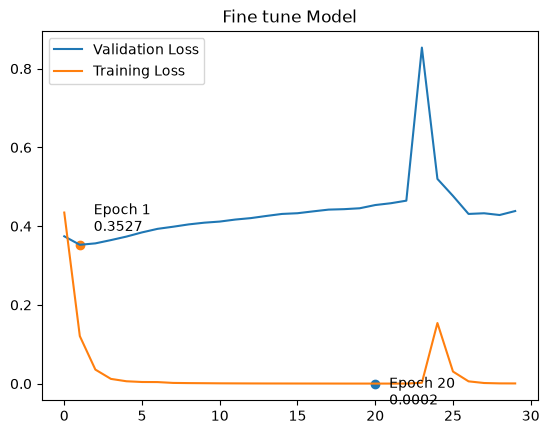

In [36]:
plot_train_val_loss_curve(fine_tune_model_train_losses, fine_tune_model_val_losses, "Fine tune Model")

### Comparing training accuracy vs validation accuracy

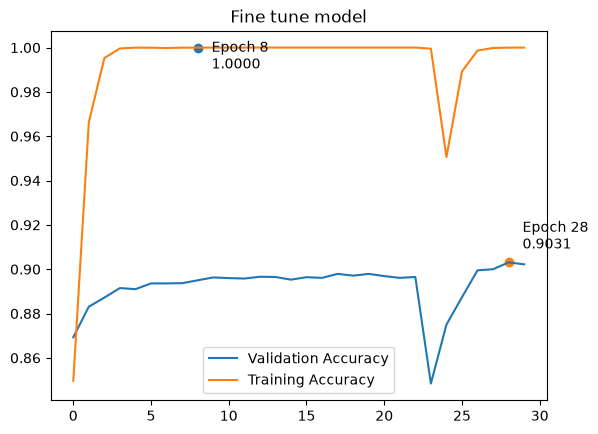

In [37]:
plot_train_val_accuracy_curve(fine_tune_model_train_accuracies, fine_tune_model_val_accuracies, "Fine tune model")

### Classification Report

In [38]:
from sklearn.metrics import classification_report

fine_tune_model = resnet18(weights=None)

fine_tune_model.fc = nn.Linear(in_features=fine_tune_model.fc.in_features, out_features=10)

fine_tune_model.load_state_dict(
    torch.load(os.path.join(fine_tune_checkpoint_path, "best_fine_tune_model.pt"), map_location=device)
)

fine_tune_model = fine_tune_model.to(device)

fine_tune_model.eval()

fine_tune_model_predictions = []
true_labels = []

with torch.no_grad():

    for images, labels in pretrained_val_loader:

        images = images.to(device)
        labels = labels.to(device)

        fine_tune_model_output = fine_tune_model(images)

        fine_tune_model_predictions.extend(
            fine_tune_model_output.argmax(dim=1).cpu().numpy()
        )

        true_labels.extend(
            labels.cpu().numpy()
        )

print(
    "Fine Tune Model:\n",
    classification_report(true_labels, fine_tune_model_predictions)
)

gc.collect()
torch.cuda.empty_cache()

Fine Tune Model:
               precision    recall  f1-score   support

           0       0.90      0.90      0.90      1000
           1       0.96      0.94      0.95      1000
           2       0.89      0.80      0.84      1000
           3       0.80      0.75      0.77      1000
           4       0.87      0.86      0.86      1000
           5       0.78      0.87      0.82      1000
           6       0.90      0.93      0.91      1000
           7       0.87      0.90      0.89      1000
           8       0.92      0.95      0.93      1000
           9       0.93      0.94      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



## Comparing all Models

| Model                       | Initialization | Trainable Layers   | Validation Accuracy |
|-----------------------------|----------------|--------------------|-------------:|
| Scratch CNN                 | Random         | Entire CNN         |       74.09% |
| ResNet18 Feature Extraction | ImageNet       | None               |       78.68% |
| ResNet18 Fine-tuning        | ImageNet       | Layer4             |       88.00% |

### Why did allowing layer4 to train improve performance from 78.68% to 88%?
- Since layer 4 more responsible for learning complex patterns in images it tends to get dataset specific so when we let it train it learns patterns form new dataset this increasing accuracy.   

### Why did we use a smaller learning rate (1e-4) for fine-tuning than for the scratch CNN (1e-3)?
- Smaller learning rate can be used because it is not being trained from scratch it is already initialized and keeping it learning rate smaller also makes it's learning more stable.

### Why did we freeze layer1, layer2, and layer3 instead of immediately fine-tuning the entire ResNet? 
- Since earlier model tend to learn general features of images such as lines, texture and common shape training them from scratch will increase marginal performance and depending on the dataset it might also overfit.

### What does the 88% result tell you about the assumption that ImageNet features are already optimal for CIFAR-10?
- It tells me that they are not because after unfreezing layer 4 accuracy increased by ~9%.

### Looking at the class-level F1 scores, which classes remain difficult and what additional experiment would you perform to investigate why?
- Class 3 still remains difficult to identify. Additional experiment that i would do is create confusion matrix to check which classes it is being misclassified with then display those images and make hypothesis after that i will try to solve it using controlled experiment and compare F1 score and recall.

## Critical Comparison

1. Was transfer learning better than training from scratch?
    - Yes. The ResNet18-based transfer-learning approach performed better than the CNN trained from scratch. The scratch CNN achieved 74.09% validation accuracy, while the fine-tuned ResNet18 achieved 88.00%.

2. Was the improvement worth the additional complexity?
    - In this experiment, the additional complexity was associated with a substantial improvement in validation accuracy. The fine-tuned ResNet18 achieved 88.00% compared with 74.09% for the scratch CNN, an improvement of 13.91 percentage points.

3. How much of the pretrained network needed to be changed?
    - I kept the earlier ResNet18 layers frozen and fine-tuned layer4 along with the new classification layer (fc). The original ImageNet classification layer was replaced with a new linear layer that outputs 10 classes for CIFAR-10.

4. Did fine-tuning improve over feature extraction?
    - Yes. Feature extraction achieved 78.68% validation accuracy, while fine-tuning layer4 and the classification layer achieved 88.00%, an improvement of 9.32 percentage points.

5. What happened when the learning rate was changed?
    - A smaller learning rate makes smaller parameter updates. This is useful during fine-tuning because the pretrained layers already contain useful learned representations. Using a smaller learning rate allows the pretrained parameters to adapt gradually to the target dataset instead of making large updates that could damage useful pretrained features.

6. When would you choose training from scratch instead?
    - I would consider training from scratch when a suitable pretrained model is unavailable, when the target domain is substantially different from the pretraining domain, or when I have enough task-specific data and computational resources to learn useful representations from the beginning.